# Skadetriagering efter förutsagd slutlig allvarlighetsgrad

## Sammanfattning

Sakförsäkringsbolag vill att deras mest erfarna skadereglerare arbetar med de skador som i slutänden kommer att kosta mest. Den här notebooken bygger en **allvarlighetstriageringsmodell** på en syntetisk portfölj av 80 personskadeärenden och visar hur den kan omvandlas till en dirigeringsregel.

Arbetsflödet består av tre delar:

- **PROC MEANS** etablerar baslinjen: medelvärde och median för slutlig allvarlighetsgrad per skadetyp, så att vi vet vilka kategorier som bär den tunga svansen innan någon modellering görs.
- **PROC UNIVARIATE** bekräftar att allvarlighetsfördelningen är starkt högersned (skevhet ≈ 1,7) och rapporterar ett fördelningsfritt 2,5/97,5-percentilband via `PCTLPTS=` — det praktiska intervallet "liten skada kontra stor förlust" som ett triageringsteam resonerar kring.
- **PROC GENMOD** anpassar en **gamma-GLM med en log-länk**, den aktuariska standardformen för positiva, högersneda förlustbelopp. Från den avläser vi **allvarlighetsrelativiteter** (`ESTIMATE ... / EXP`) och minsta-kvadrat-medelvärden per skadetyp (`LSMEANS ... / ILINK`) som exponentieras till en allvarlighetsbaslinje på dollarskalan.

Den anpassade modellen återskapar den avsedda strukturen: relativt en mjukdels-**Strain** löper en **Fracture** ungefär **3,25×** och en **Head**-skada ungefär **1,67×** den förväntade slutliga allvarlighetsgraden; **advokatinblandning** lägger till ungefär **+47 %**; och allvarlighetsgraden stiger måttligt med skadelidandes ålder och rapporteringsfördröjning. Typ 3-sannolikhetskvottest bekräftar att varje effekt är signifikant. Översatt till drift: dirigera frakturer, huvudskador och alla advokatföreträdda ärenden till seniora skadereglerare, och låt de högvolyms-lågallvarliga stukningarna flöda till snabbspåret.

## Datakällor

**Syntetiskt dataset `claims`** — 80 personskadeärenden genererade inline med `streaminit`/`rand` (inga externa filer). Slutlig allvarlighetsgrad dras från en gammafördelning vars log-medelvärde följer kovariaterna nedan, så att modellen har en känd grundsanning att återskapa.

| Variabel | Typ | Beskrivning |
|----------|------|-------------|
| `claim_id` | Num | Unik ärendeidentifierare (1–80) |
| `injury_type` | Char | Skadekategori: `Strain` (~45 %), `Fracture` (~33 %), `Head` (~22 %) |
| `claimant_age` | Num | Skadelidandes ålder i år (22–66) |
| `report_lag` | Num | Antal dagar från skadedatum till första rapportering (1–60) |
| `attorney` | Char | Flagga för advokatinblandning (`Yes` ~30 % / `No`) |
| `severity` | Num | Slutlig ådragen allvarlighetsgrad i dollar (gammafördelad, högersned) |

# Skadetriagering efter förutsagd slutlig allvarlighetsgrad

**Affärsproblem.** Inkommande skador anländer snabbare än vad seniora skadereglerare hinner granska dem. Om vi kan förutsäga *slutlig allvarlighetsgrad* vid inregistrering utifrån några få billiga inregistreringsfält kan vi dirigera de sannolikt stora förlusterna till erfarna skadereglerare och snabbspåra resten. Den här notebooken bygger den modellen från början till slut och avläser de **allvarlighetsrelativiteter** som styr dirigeringsregeln.

**Tillvägagångssätt.**
1. `PROC MEANS` — baslinjens medelvärde/median för allvarlighetsgrad per skadetyp.
2. `PROC UNIVARIATE` — bekräfta högerskevheten och ett 2,5/97,5-percentilband.
3. `PROC GENMOD` — en gamma-GLM (log-länk) för förutsagd allvarlighetsgrad, med relativiteter och invers-länkade LS-medelvärden.

## 1. Generera en syntetisk portfölj av skadeärenden

Den första cellen bygger data inline. Slutlig allvarlighetsgrad är ett **gammadrag** vars log-medelvärde beror på skadetyp, skadelidandes ålder, rapporteringsfördröjning och advokatinblandning — så att GLM:en nedströms har en känd struktur att återskapa. Vi håller portföljen till 80 ärenden så att varje steg körs på sekunder.

In [1]:
ALTERNATIV linesize=96;

data claims;
    CALL streaminit(20260606);
    LÄNGD injury_type $12 attorney $3;
    GÖR claim_id = 1 TILL 80;
        u = rand('uniform');
        OM u < 0.45 SÅ injury_type = 'Strain';
        ANNARS OM u < 0.78 SÅ injury_type = 'Fracture';
        ANNARS injury_type = 'Head';

        claimant_age = round(22 + (66-22)*rand('uniform'));
        report_lag   = round(1 + (60-1)*rand('uniform'));

        OM rand('uniform') < 0.30 SÅ attorney = 'Yes';
        ANNARS attorney = 'No';

        /* log-mean of ultimate severity */
        eta = 8.4
            + ifn(injury_type='Fracture', 0.55, 0)
            + ifn(injury_type='Head',     1.15, 0)
            + 0.012*(claimant_age - 44)
            + 0.009*report_lag
            + ifn(attorney='Yes', 0.45, 0);
        MU = EXP(eta);

        /* gamma draw, shape ~ 6 keeps a realistic right tail */
        shape = 6;
        severity = MU * rand('gamma', shape) / shape;
        severity = round(severity, 1);
        UTDATA;
    SLUT;
    BEHÅLL claim_id injury_type claimant_age report_lag attorney severity;
KÖR;

NOTE: Option LINESIZE changed to 96.
NOTE: DATA claims


NOTE: Wrote claims (80 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## 2. Baslinjens allvarlighetsgrad per skadetyp

Innan modellering, titta på var pengarna finns. `PROC MEANS` med en `CLASS` visar medelvärde, standardavvikelse och median för allvarlighetsgrad per skadetyp. Gapet mellan medelvärde och median är det första tecknet på en tung högersvans — och huvudskador bör dominera.

In [2]:
PROCEDUR MEDELVÄRDEN data=claims n mean std MEDIAN maxdec=0;
    KLASS injury_type;
    VARIABEL severity;
KÖR;

                                      The MEANS Procedure

                                  Analysis Variable : SEVERITY

        INJURY_TYPE          N Obs           Mean        Std Dev         Median
        -----------------------------------------------------------------------
        Fracture                27          12606           5749          12325
        Head                    17          23406          11539          22132
        Strain                  36           6923           3251           6019
        -----------------------------------------------------------------------



NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 3. Allvarlighetsfördelningen är högersned

Förlustbelopp är positiva och långsvansade, vilket är precis anledningen till att vi inte kommer att modellera dem med vanliga minsta kvadratmetoden. `PROC UNIVARIATE` rapporterar momenten (håll koll på den positiva skevheten) och ett **fördelningsfritt 2,5/97,5-percentilband** via `PCTLPTS=` — det praktiska intervallet "rutinärende kontra stor förlust" som ett triageringsteam resonerar kring. Vi skriver ut bandet som sin egen lilla tabell.

In [3]:
PROCEDUR UNIVARIATE data=claims;
    VARIABEL severity;
    UTDATA out=sevpct pctlpts=2.5 97.5 pctlpre=p_ pctlname=lo hi;
KÖR;

PROCEDUR SKRIV data=sevpct noobs;
KÖR;

                                    The UNIVARIATE Procedure
                                      Variable:  SEVERITY

                                            Moments

N                                 80    Sum Weights                       80
Mean                    12343.862500    Sum Observations       987509.000000
Std Deviation            9070.527295    Variance              82274465.411234
Skewness                    1.745092    Kurtosis                    3.693069
Uncorrected SS        18689358081.000000    Corrected SS          6499682767.487494
Coeff Variation            73.482083    Std Error Mean           1014.115781

              Basic Statistical Measures              

Location                Variability                   
--------  ------------  -------------  ---------------
Mean      12343.862500  Std Deviation      9070.527295
Median     9892.000000  Variance       82274465.411234
Mode      12432.000000  Range             46966.000000

Quantiles (Definition 5)

NOTE: PROC UNIVARIATE
NOTE: Output dataset sevpct has 1 observations and 2 variables.
NOTE: PROC PRINT data=sevpct

NOTE: PROC PRINT completed: 1 observations printed, 2 variables


## 4. Gamma-/log-GLM för förutsagd slutlig allvarlighetsgrad

Den aktuariska arbetshästen för positiva, högersneda förluster är en **generaliserad linjär modell med en gammafördelning och en log-länk** — den multiplikativa formen innebär att varje kovariat skalar den förväntade allvarlighetsgraden, vilket ger direkt tolkningsbara **relativiteter**.

- `MODEL ... / DIST=GAMMA LINK=LOG TYPE3 CL` anpassar modellen med Typ 3-sannolikhetskvottest och konfidensgränser.
- `ESTIMATE ... / EXP` exponentierar varje kontrast, så `Exp(Est)` är allvarlighets*multiplikatorn* (t.ex. Fracture kontra Strain).
- `LSMEANS injury_type / CL ILINK` rapporterar varje skadetyps förväntade **log-allvarlighet** (kolumnen `Estimate`), med övriga kovariater hållna vid sina medelvärden; exponentiering av dessa skattningar ger den baslinje på dollarskalan som används i triageringsregeln nedan.

Observera `quit;` efter `run;` — `PROC GENMOD` är en run-group-proc, så `quit;` tömmer dess utdata rent i notebooken.


      The GENMOD Procedure      
       Model Information        

Item                       Value
----------------------  --------
Response Variable       SEVERITY
Distribution               gamma
Link Function                log
Number of Observations        80

      Analysis of Maximum Likelihood Parameter Estimates      

Parameter          Estimate  Std Error  Chi-Square  Pr > ChiSq
-----------------  --------  ---------  ----------  ----------
(Intercept)          8.6199     0.2348   1348.0405      <.0001
INJURY_TYPEHead      0.6664     0.1281     27.0473      <.0001
INJURY_TYPEStrain   -0.5136     0.1057     23.6185      <.0001
CLAIMANT_AGE         0.0086     0.0038      5.1815      0.0228
REPORT_LAG           0.0069     0.0027      6.3882      0.0115
ATTORNEYYes          0.3822     0.1050     13.2459      0.0003

Criteria for Assessing Goodness of Fit

Criterion           Value
--------------  ---------
Deviance          13.3551
Log Likelihood  -778.1944
AIC             1570

NOTE: PROC GENMOD data=claims

NOTE: PROC GENMOD using R wrapper
NOTE: 
NOTE: Response Variable: SEVERITY
NOTE: Distribution: GAMMA
NOTE: Link Function: LOG
NOTE: Number of Observations: 80
NOTE:   Model fitted successfully with 80 observations
NOTE: ODS plot written: genmod_residuals_vs_predicted.spec.json
NOTE: ODS plot written: genmod_residual_histogram_panel.spec.json
NOTE: ODS plot written: genmod_residuals_vs_obs_order.spec.json
NOTE: ODS plot written: genmod_qq_plot.spec.json
NOTE: PROC GENMOD ODS Graphics generated.


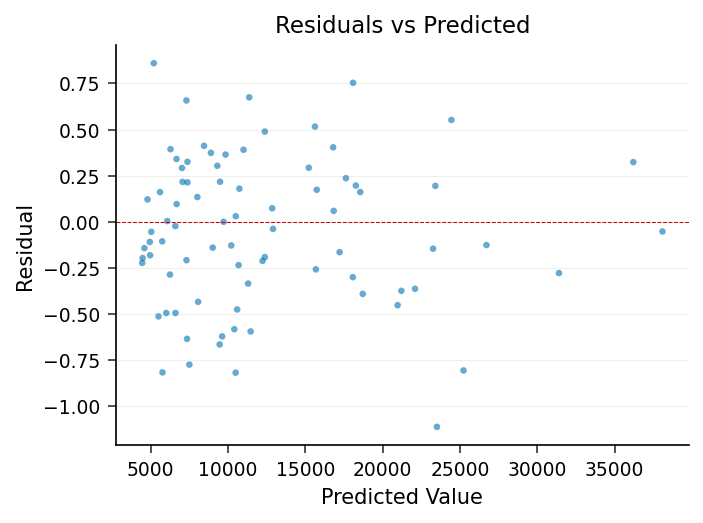

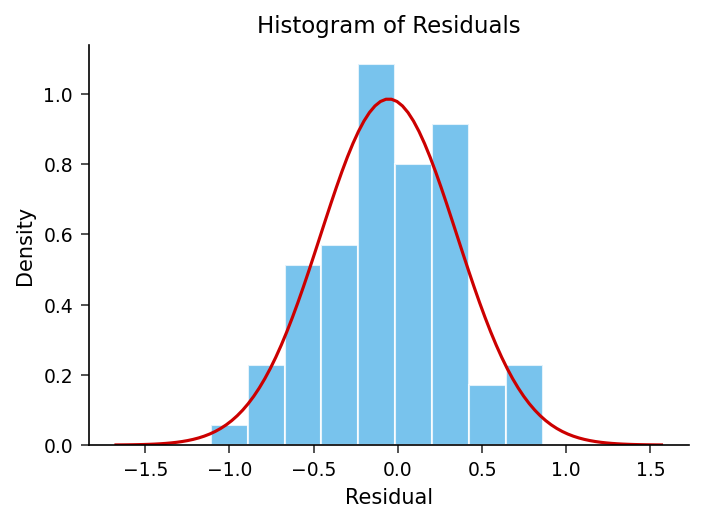

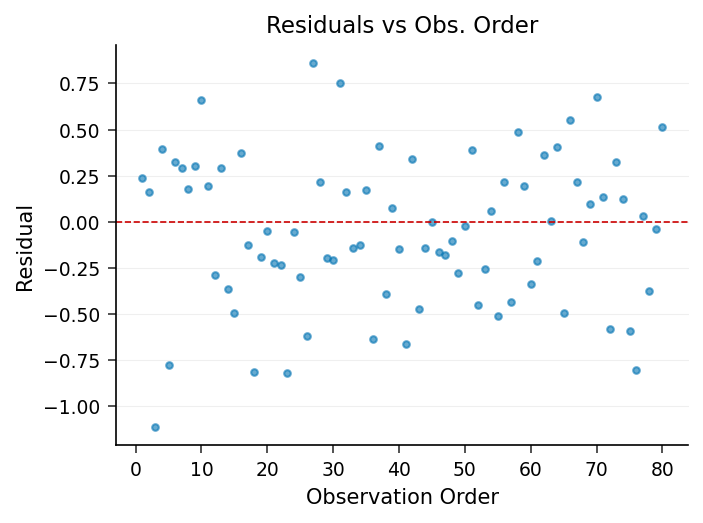

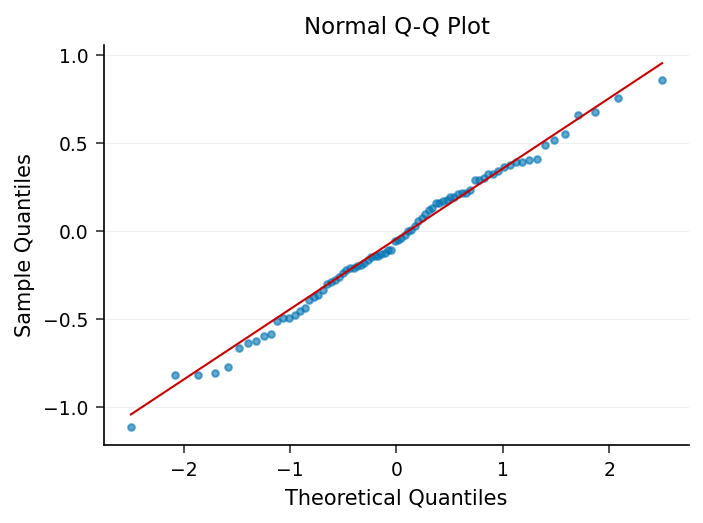

In [4]:
PROCEDUR GENMOD data=claims;
    KLASS injury_type attorney;
    MODEL severity = injury_type claimant_age report_lag attorney
          / DIST=gamma LINK=LOG type3 cl;
    ESTIMATE 'Fracture vs Strain' injury_type 0 1 -1 / EXP;
    ESTIMATE 'Head vs Strain'     injury_type 1 0 -1 / EXP;
    ESTIMATE 'Attorney Yes vs No' attorney -1 1 / EXP;
    LSMEANS injury_type / cl ILINK;
KÖR;
QUIT;

## 5. Tolkning och triageringsregeln

Gamma-GLM:en återskapar den struktur vi byggde in:

- **Skadetyp dominerar.** Relativt en mjukdels-**Strain** bär en **Fracture** ungefär **3,25×** den förväntade slutliga allvarlighetsgraden och en **Head**-skada ungefär **1,67×** (båda `Exp(Est)`-värden, p < .0001). Typ 3-testet för `INJURY_TYPE` är överväldigande signifikant (χ² ≈ 96 med 2 fg).
- **Advokatinblandning lägger till ungefär +47 %** till förväntad allvarlighetsgrad (relativitet ≈ 1,47, p ≈ .0003) — en stark, billig-att-observera eskaleringssignal vid inregistrering.
- **Ålder och rapporteringsfördröjning** driver upp allvarlighetsgraden måttligt men signifikant (p ≈ .023 och .012): äldre skadelidande och långsammare rapporterade ärenden kostar mer, i linje med fördröjda/komplexa förluster.

**Dollarbaslinje.** Exponentiering av LS-medelvärdena på log-skalan ger den förväntade allvarlighetsgraden per skadetyp vid genomsnittlig ålder, rapporteringsfördröjning och advokatmix: **Strain ≈ \$6 300** (LS-medelvärde 8,74), **Fracture ≈ \$10 500** (9,26), **Head ≈ \$20 400** (9,92). Dessa speglar de råa `PROC MEANS`-medelvärdena men är justerade för de övriga kovariaterna.

**Operativ regel.** Poängsätt varje nytt ärende genom att multiplicera den relevanta skadetypsbaslinjen med advokatrelativiteten (och justeringarna för ålder / rapporteringsfördröjning), och dirigera sedan efter förutsagd allvarlighetsgrad:

- **Senior skadereglerare:** alla Head- eller Fracture-ärenden, *eller* alla advokatföreträdda ärenden, *eller* en kombination av hög ålder × lång rapporteringsfördröjning.
- **Snabbspår:** icke företrädda stukningar som rapporterats omgående — den högvolyms-, lågallvarliga huvuddelen av portföljen.

Eftersom modellen är multiplikativ är relativiteterna portabla: ett teckningss- eller skadeteam kan tillämpa dem på sin egen portföljs baslinjeallvarlighet utan att härleda dollarinterceptet på nytt. Samma `GENMOD`-anrop, återanpassat periodvis på avslutade ärenden, håller triageringströsklarna kalibrerade allt eftersom portföljen utvecklas.